## Gridded dataset Eploratory Analysis
Confirm Path and Open the 2024 File
Since the file is there, let's confirm the path and open it in your Jupyter notebook:

In [ ]:
current_directory = os.getcwd()
print(f"The current working directory is: {current_directory}")


The current working directory is: /home/roddyb/projects/wheatbelt_rainfall_analyser/notebooks


In [ ]:
import xarray as xr
import os
import cftime

# Define the path to the 2024 file
# nc_file = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/gridded/2024.monthly_rain.nc"
nc_file = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2024.monthly_rain.nc"
# Check if file exist

if not os.path.exists(nc_file):
    print(f"❌ File not found: {nc_file}")
else:
    print(f"✅ File found: {nc_file}")

    # Open the NetCDF file without automatic time decoding
    dataset = xr.open_dataset(nc_file)
    
    # Display dataset information
    print(dataset)
    print(dataset["time"])
    print("\nTime Metadata:", dataset["time"].attrs)
    
   

✅ File found: /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2024.monthly_rain.nc
<xarray.Dataset> Size: 55MB
Dimensions:       (lat: 681, lon: 841, time: 12)
Coordinates:
  * lat           (lat) float64 5kB -44.0 -43.95 -43.9 ... -10.1 -10.05 -10.0
  * lon           (lon) float64 7kB 112.0 112.0 112.1 ... 153.9 153.9 154.0
  * time          (time) datetime64[ns] 96B 2024-01-16T12:00:00 ... 2024-12-1...
Data variables:
    monthly_rain  (time, lat, lon) float64 55MB ...
    crs           |S1 1B ...
Attributes:
    department:               Department of Environment and Science
    department_short:         DES
    copyright:                Copyright - the State of Queensland Department ...
    site_url:                 http://www.longpaddock.qld.gov.au
    institution:              Queensland Government, Department of Environmen...
    raster_source:            Gridded surface was created by interpolating ob...
    raster_source_additions:  and other suppl

## Explore the Dataset
Examine the contents of the NetCDF file:

In [ ]:
# Check the structure of the data variable
rainfall = dataset["monthly_rain"]
# rainfall = dataset["precip"]
print("\n🌧️ Rainfall Data Structure:")
print(rainfall)

# Check min, max, and mean rainfall values
print("\n📊 Rainfall Statistics:")
print(f"Min: {rainfall.min().values:.2f} mm")
print(f"Max: {rainfall.max().values:.2f} mm")
print(f"Mean: {rainfall.mean().values:.2f} mm")

# Check the first few time values
print("\n🕒 Time Coordinate Values:")
print(dataset["time"].values)
print("Type:", type(dataset["time"]))

# Check the lat/lon range
print("\n🌍 Spatial Coverage:")
print(f"Latitude range: {dataset.lat.values.min()} to {dataset.lat.values.max()}")
print(f"Longitude range: {dataset.lon.values.min()} to {dataset.lon.values.max()}")






🌧️ Rainfall Data Structure:
<xarray.DataArray 'monthly_rain' (time: 12, lat: 681, lon: 841)> Size: 55MB
[6872652 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 5kB -44.0 -43.95 -43.9 -43.85 ... -10.1 -10.05 -10.0
  * lon      (lon) float64 7kB 112.0 112.0 112.1 112.2 ... 153.9 153.9 154.0
  * time     (time) datetime64[ns] 96B 2024-01-16T12:00:00 ... 2024-12-16T12:...
Attributes:
    long_name:  Monthly rainfall
    units:      mm
    valid_min:  -32765
    valid_max:  32767

📊 Rainfall Statistics:
Min: 0.00 mm
Max: 1795.00 mm
Mean: 49.10 mm

🕒 Time Coordinate Values:
['2024-01-16T12:00:00.000000000' '2024-02-15T12:00:00.000000000'
 '2024-03-16T12:00:00.000000000' '2024-04-16T00:00:00.000000000'
 '2024-05-16T12:00:00.000000000' '2024-06-16T00:00:00.000000000'
 '2024-07-16T12:00:00.000000000' '2024-08-16T12:00:00.000000000'
 '2024-09-16T00:00:00.000000000' '2024-10-16T12:00:00.000000000'
 '2024-11-16T00:00:00.000000000' '2024-12-16T12:00:00.000000000']
Type: <class 

## Extract Monthly Rainfall Data for a Specific Location
Assume you want data for latitude -33.0 and longitude 150.0:

In [1]:
# Select nearest grid point
lat, lon = -27.54, 151.91
nearest_lat = dataset.lat.sel(lat=lat, method="nearest").values
nearest_lon = dataset.lon.sel(lon=lon, method="nearest").values
print(f"\n📍 Nearest Grid Point: Lat={nearest_lat}, Lon={nearest_lon}")

# Extract rainfall time series for this location
# rainfall_location = dataset.sel(lat=nearest_lat, lon=nearest_lon)["precip"]
rainfall_location = dataset.sel(lat=nearest_lat, lon=nearest_lon)["monthly_rain"]
print("\n🌧️ Monthly Rainfall at Selected Location:")
print(rainfall_location.values)
print(rainfall_location)


NameError: name 'dataset' is not defined

## Visualize Monthly Rainfall Trends
Create a time-series plot to visualize the data:

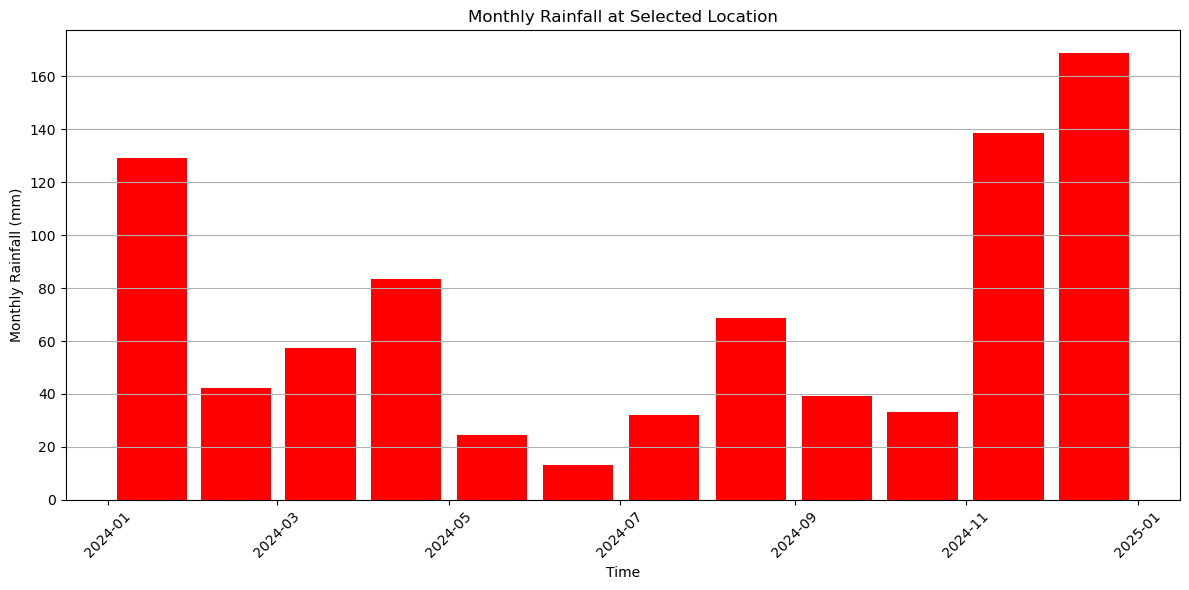

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming rainfall_location has a time dimension named "time"
time = rainfall_location['time']
rainfall_values = rainfall_location.values

# Define bar width as a timedelta of 25 days
bar_width = np.timedelta64(25, 'D')  # Adjust the number of days as needed

plt.figure(figsize=(12, 6))
plt.bar(time, rainfall_values, color='r', width=bar_width)
plt.xlabel('Time')
plt.ylabel('Monthly Rainfall (mm)')  # Adjust the unit if necessary
plt.title('Monthly Rainfall at Selected Location')
plt.grid(True, axis='y')  # Only show grid lines for the y-axis

# Rotate date labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [8]:
import fiona
import geopandas as gpd

print("Fiona version:", fiona.__version__)
print("GeoPandas version:", gpd.__version__)

Fiona version: 1.10.1
GeoPandas version: 0.14.4


## Extracting June Rainfall Data and Generating a Color-Mapped GeoTIFF
This Jupyter Notebook snippet demonstrates a two-step process to visualize June monthly rainfall data from a NetCDF file. First, it extracts the June time-slice (band 6) using gdal_translate, setting the appropriate nodata value and spatial reference system. Then, it converts the temporary NetCDF output to a color-mapped GeoTIFF using gdaldem color-relief, which applies a specified color ramp for enhanced visualization.

In [6]:
import subprocess

# Define the file paths
input_nc = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/bom_feb.nc"
tmp_nc = "tmp.nc"
clr_file = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/colormaps/monthly_rain.clr"
output_tif = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/interim/202501.BOMmonthly_rain.tif"

# Step 1: Extract the June time-slice using gdal_translate.
# For your monthly file, the 6th band corresponds to June.
translate_cmd = [
    "gdal_translate",
    input_nc,      # Source file
    tmp_nc,        # Temporary output file
    "-of", "NetCDF",
    "-ot", "Float32",
    "-b", "1",     # Extract band 6 (June)
    "-unscale",
    "-a_nodata", "-32765",  # Set nodata value (as per your file attributes)
    "-a_srs", "epsg:4326"    # Assign the WGS84 coordinate system
]

print("Running gdal_translate command...")
subprocess.run(translate_cmd, check=True)
print("gdal_translate completed.")

# Step 2: Convert the temporary NetCDF file to a GeoTIFF using gdaldem color-relief.
color_relief_cmd = [
    "gdaldem", "color-relief",
    tmp_nc,      # Input temporary NetCDF file
    clr_file,    # Color map file for monthly rainfall
    output_tif,  # Output GeoTIFF file
    "-of", "GTiff",
    "-alpha",
    "-nearest_color_entry",
    "-co", "COMPRESS=DEFLATE"
]

print("Running gdaldem color-relief command...")
subprocess.run(color_relief_cmd, check=True)
print("gdaldem color-relief completed. GeoTIFF saved to:", output_tif)


Running gdal_translate command...
Input file size is 886, 691
0...10...20...30...40...50...60...70...80...90...100 - done.
gdal_translate completed.
Running gdaldem color-relief command...
0...10...20...30...40...50...60...70...80...90...100 - done.
gdaldem color-relief completed. GeoTIFF saved to: /home/roddyb/projects/wheatbelt_rainfall_analyser/data/interim/202501.BOMmonthly_rain.tif


## Overlay with Australian States and SD Regions in Python
Use the following Python script to open the GeoTIFF and overlay it with the boundaries from your vector data. Adjust the file paths for your shapefiles accordingly.

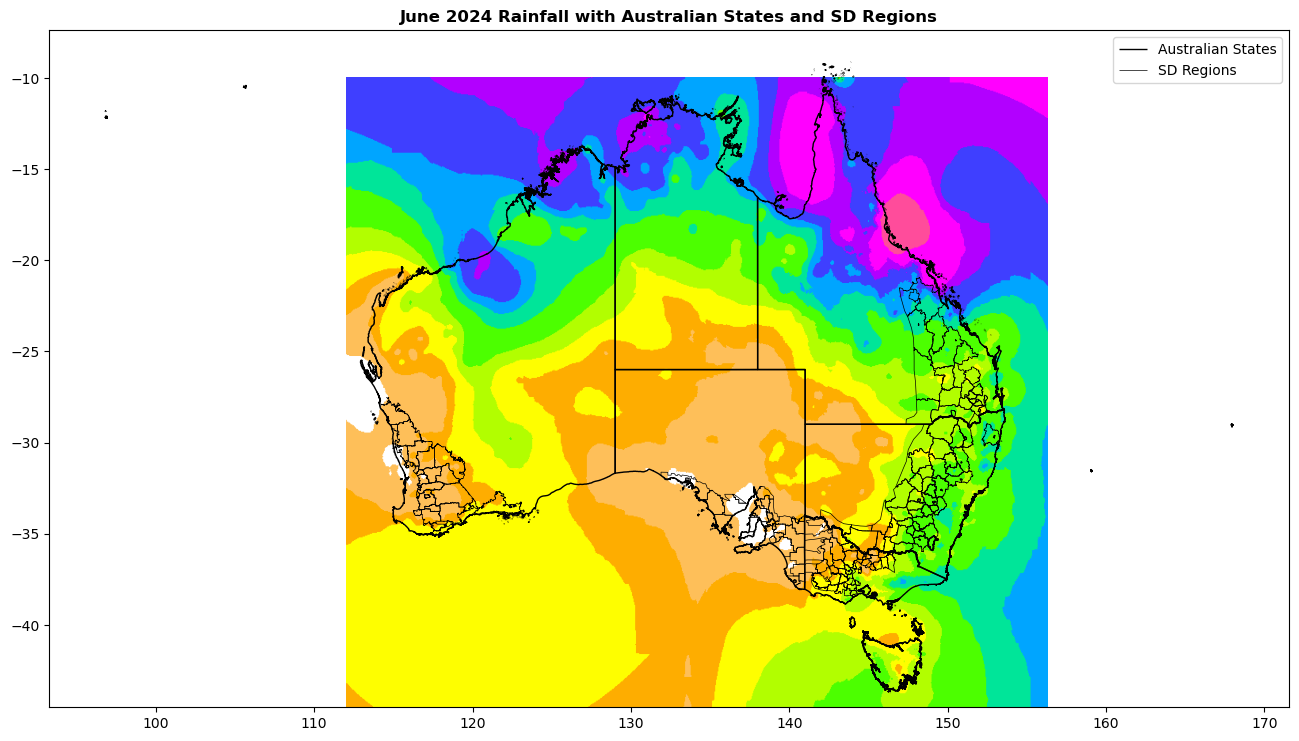

In [7]:
# Overlay with Australian States and SD Regions in Python
import rasterio
from rasterio.plot import show
import geopandas as gpd
import matplotlib.pyplot as plt

# Define paths to your data
geotiff_path = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/interim/202501.BOMmonthly_rain.tif"

# Update these paths to the location of your shapefiles
states_shp = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/STE_2021_AUST_GDA2020/STE_2021_AUST_GDA2020.shp"
sd_regions_shp = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/Australia_SA2_Wheat_clipped/Australia_SA2_Wheat_clipped.shp"

# Open the GeoTIFF using Rasterio
with rasterio.open(geotiff_path) as src:
    raster_crs = src.crs  # Get the coordinate reference system of the raster
    fig, ax = plt.subplots(figsize=(16, 12))
    show(src, ax=ax, title="June 2024 Rainfall with Australian States and SD Regions")

# Load the Australian states shapefile using GeoPandas
states = gpd.read_file(states_shp)

# Load the SD regions shapefile using GeoPandas
sd_regions = gpd.read_file(sd_regions_shp)

# Reproject vector data to match the raster CRS (if needed)
if states.crs != raster_crs:
    states = states.to_crs(raster_crs)
if sd_regions.crs != raster_crs:
    sd_regions = sd_regions.to_crs(raster_crs)

# Overlay the boundaries on the existing raster plot
states.boundary.plot(ax=ax, edgecolor="black", linewidth=1, label="Australian States")
sd_regions.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, label="SD Regions")

# Add a legend and display the plot
plt.legend()
plt.show()


## Goose suggestions

In [1]:
import xarray as xr
import os

nc_file = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2025.monthly_rain.nc"

if not os.path.exists(nc_file):
    print(f"❌ File not found: {nc_file}")
else:
    try:
        with xr.open_dataset(nc_file) as dataset:
            print(f"✅ File found: {nc_file}")
            print(dataset)
    except IOError as e:
        print(f"❌ Error opening file: {e}")

✅ File found: /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2025.monthly_rain.nc
<xarray.Dataset> Size: 5MB
Dimensions:       (lat: 681, lon: 841, time: 1)
Coordinates:
  * lat           (lat) float64 5kB -44.0 -43.95 -43.9 ... -10.1 -10.05 -10.0
  * lon           (lon) float64 7kB 112.0 112.0 112.1 ... 153.9 153.9 154.0
  * time          (time) datetime64[ns] 8B 2025-01-16T12:00:00
Data variables:
    monthly_rain  (time, lat, lon) float64 5MB ...
    crs           |S1 1B ...
Attributes:
    department:               Department of Environment and Science
    department_short:         DES
    copyright:                Copyright - the State of Queensland Department ...
    site_url:                 http://www.longpaddock.qld.gov.au
    institution:              Queensland Government, Department of Environmen...
    raster_source:            Gridded surface was created by interpolating ob...
    raster_source_additions:  and other suppliers (see the SILO we

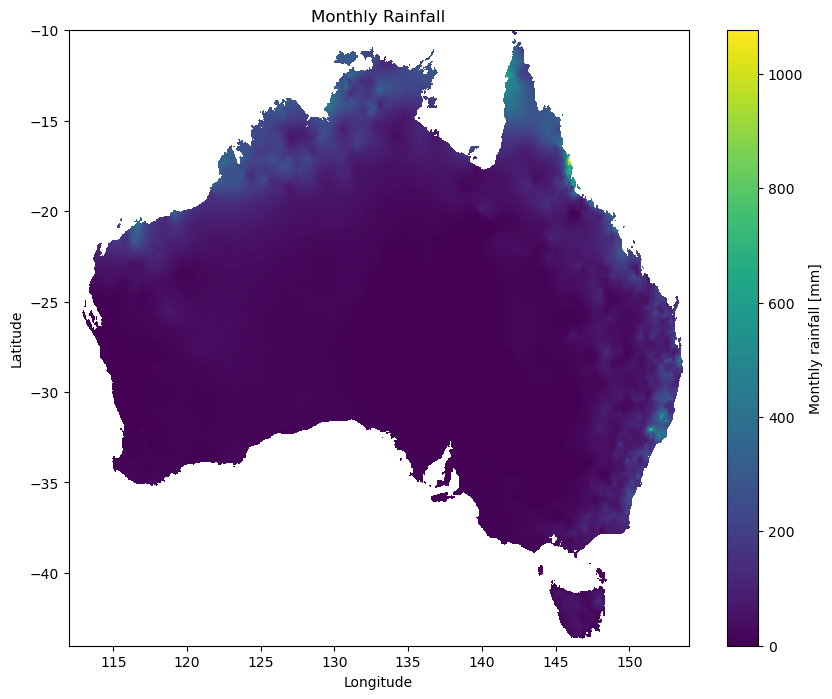

In [2]:
import matplotlib.pyplot as plt

rainfall = dataset["monthly_rain"]
plt.figure(figsize=(10, 8))
rainfall.plot(cmap="viridis")  # Choose an appropriate colormap
plt.title("Monthly Rainfall")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [20]:
lat, lon = -27.54, 151.91
tolerance = 0.1  # Adjust as needed

try:
    nearest_lat = dataset.lat.sel(lat=lat, method="nearest", tolerance=tolerance).values
    nearest_lon = dataset.lon.sel(lon=lon, method="nearest", tolerance=tolerance).values
    print(f"📍 Nearest Grid Point: Lat={nearest_lat}, Lon={nearest_lon}")

    rainfall_location = dataset.sel(lat=nearest_lat, lon=nearest_lon)["monthly_rain"]
    print(" Monthly Rainfall at Selected Location:")
    print(rainfall_location.values)
    print(rainfall_location)

except KeyError as e:
    print(f"❌ Coordinate selection failed: {e}")
except ValueError as e:
    print(f"❌ No coordinates found within tolerance: {e}")

📍 Nearest Grid Point: Lat=-27.55, Lon=151.9
 Monthly Rainfall at Selected Location:
[82.6]
<xarray.DataArray 'monthly_rain' (time: 1)> Size: 8B
array([82.6])
Coordinates:
    lat      float64 8B -27.55
    lon      float64 8B 151.9
  * time     (time) datetime64[ns] 8B 2025-01-16T12:00:00
Attributes:
    long_name:  Monthly rainfall
    units:      mm
    valid_min:  -32765
    valid_max:  32767


In [23]:
 #*Extract June Rainfall by Date:**

# Convert time to datetime objects if it's not already
dataset['time'] = dataset['time'].astype('datetime64[ns]')

# Select June data. Assumes time is in YYYY-MM-DD format
try:
    june_rainfall = dataset["monthly_rain"].sel(time=dataset["time"].dt.month == 6)
except KeyError as e:
    print(f"❌ Could not find the variable monthly_rain")
except IndexError as e:
    print(f"❌ No data for June found in this dataset.")


In [25]:
def average_yearly_nc(directory, output_file):
    """Averages yearly .nc files in a directory using cdo."""

    nc_files = [f for f in os.listdir(directory) if f.endswith(".nc")]
    if not nc_files:
        return "No .nc files found in the directory."

    input_files_str = " ".join([os.path.join(directory, f) for f in nc_files])
    output_path = os.path.join(directory, output_file)
    command = f"cdo avg {input_files_str} {output_path}"

    return command

directory = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain"
output_file = "average_rainfall.nc"
cdo_command = average_yearly_nc(directory, output_file)
print(cdo_command)

cdo avg /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2019.monthly_rain.nc /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2012.monthly_rain.nc /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2021.monthly_rain.nc /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2015.monthly_rain.nc /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2005.monthly_rain.nc /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2022.monthly_rain.nc /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2014.monthly_rain.nc /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2018.monthly_rain.nc /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2025.monthly_rain.nc /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/bom_Jan.nc /home/roddyb/projects/

Current working directory: /home/roddyb/projects/wheatbelt_rainfall_analyser/notebooks
Successfully opened /home/roddyb/projects/wheatbelt_rainfall_analyser/data/gridded/2024.monthly_rain.nc
<xarray.Dataset> Size: 55MB
Dimensions:       (lat: 681, lon: 841, time: 12)
Coordinates:
  * lat           (lat) float64 5kB -44.0 -43.95 -43.9 ... -10.1 -10.05 -10.0
  * lon           (lon) float64 7kB 112.0 112.0 112.1 ... 153.9 153.9 154.0
  * time          (time) datetime64[ns] 96B 2024-01-16T12:00:00 ... 2024-12-1...
Data variables:
    monthly_rain  (time, lat, lon) float64 55MB ...
    crs           |S1 1B ...
Attributes:
    department:               Department of Environment and Science
    department_short:         DES
    copyright:                Copyright - the State of Queensland Department ...
    site_url:                 http://www.longpaddock.qld.gov.au
    institution:              Queensland Government, Department of Environmen...
    raster_source:            Gridded surface w

### This code block opens two NetCDF files using the `xarray` library: '2024.monthly_rain.nc' and 'bom_Jan.nc'. It then checks if the 'bom_Jan.nc' dataset contains a variable named 'precip'. If it does, the code renames this variable to 'Monthly_rainfall' and saves the modified dataset to a new file na
### med 'bom_Jan_modified.nc' in the same directory. The code also prints the contents of the xarray datasets to the console for verification. Error handling is included to gracefully manage cases where the specified files are not found.

In [16]:
import xarray as xr
import os

# Define the file paths
file1_path = '/home/roddyb/projects/wheatbelt_rainfall_analyser/data/gridded/2024.monthly_rain.nc'
file2_path = '/home/roddyb/projects/wheatbelt_rainfall_analyser/data/gridded/bom_Jan.nc'

print(f"Current working directory: {os.getcwd()}")

# Open the datasets
try:
    ds1 = xr.open_dataset(file1_path)
    print(f"Successfully opened {file1_path}")
    print(ds1)
except FileNotFoundError:
    print(f"Error: {file1_path} not found.")
    ds1 = None

try:
    ds2 = xr.open_dataset(file2_path)
    print(f"Successfully opened {file2_path}")
    print(ds2)
except FileNotFoundError:
    print(f"Error: {file2_path} not found.")
    ds2 = None

# Rename the variable in the second dataset if both datasets were opened
if ds1 is not None and ds2 is not None:
    if 'precip' in ds2.variables:
        ds2 = ds2.rename({'precip': 'Monthly rainfall'})
        ds2.to_netcdf('/home/roddyb/projects/wheatbelt_rainfall_analyser/data/gridded/BOM_Jan_modified.nc') # Save modified file
        print("Renamed 'precip' to 'Monthly rainfall' and saved to /home/roddyb/projects/wheatbelt_rainfall_analyser/data/gridded/BOM_Jan_modified.nc")
    else:
        print("Variable 'precip' not found in bom_Jan.nc")

Current working directory: /home/roddyb/projects/wheatbelt_rainfall_analyser/notebooks
Successfully opened /home/roddyb/projects/wheatbelt_rainfall_analyser/data/gridded/2024.monthly_rain.nc
<xarray.Dataset> Size: 55MB
Dimensions:       (lat: 681, lon: 841, time: 12)
Coordinates:
  * lat           (lat) float64 5kB -44.0 -43.95 -43.9 ... -10.1 -10.05 -10.0
  * lon           (lon) float64 7kB 112.0 112.0 112.1 ... 153.9 153.9 154.0
  * time          (time) datetime64[ns] 96B 2024-01-16T12:00:00 ... 2024-12-1...
Data variables:
    monthly_rain  (time, lat, lon) float64 55MB ...
    crs           |S1 1B ...
Attributes:
    department:               Department of Environment and Science
    department_short:         DES
    copyright:                Copyright - the State of Queensland Department ...
    site_url:                 http://www.longpaddock.qld.gov.au
    institution:              Queensland Government, Department of Environmen...
    raster_source:            Gridded surface w

In [27]:
import netCDF4
import numpy as np
import os


def calculate_average_rainfall(data_dir):
    """
    Calculates the average rainfall for each year from NetCDF files in the given directory.

    Args:
        data_dir (str): The directory containing the NetCDF files.

    Returns:
        dict: A dictionary where keys are years and values are the average rainfall for that year.
             Returns an empty dictionary if no valid data is found.
    """
    yearly_average_rainfall = {}
    for filename in os.listdir(data_dir):
        if filename.endswith(".nc") and filename[0].isdigit():
            try:
                year = int(filename.split(".")[0])
                filepath = os.path.join(data_dir, filename)
                with netCDF4.Dataset(filepath, "r") as nc_file:
                    rainfall_data_raw = nc_file.variables["monthly_rain"][:]
                    scale_factor = nc_file.variables["monthly_rain"].scale_factor
                    add_offset = nc_file.variables["monthly_rain"].add_offset
                    fill_value = nc_file.variables["monthly_rain"]._FillValue
                    # Apply scale factor and offset
                    rainfall_data = np.where(rainfall_data_raw == fill_value, np.nan, rainfall_data_raw).astype(np.float32)
                    rainfall_data = (rainfall_data * scale_factor) + add_offset

                    print(f"Year: {year}")
                    print(f"Raw Rainfall Data: {rainfall_data_raw!r}")
                    print(f"Scaled Rainfall Data: {rainfall_data!r}")

                    # Calculate the annual average rainfall
                    annual_average = np.mean(rainfall_data)
                    yearly_average_rainfall[year] = annual_average
            except Exception as e:
                print(f"Error processing file {filename}: {e}")
                continue
            break # only process one file for debugging

    return yearly_average_rainfall



In [28]:

data_directory = '/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain'
average_rainfall = calculate_average_rainfall(data_directory)
if average_rainfall:
    for year, rainfall in average_rainfall.items():
        print(f"Year: {year}, Average Rainfall: {rainfall:.2f} mm")
else:
    print("No rainfall data found.")

Year: 2019
Raw Rainfall Data: masked_array(
  data=[[[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        ...,

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],


## Region mask
The example will compute the mean annual rainfall for Queensland.  Taken from SIL website

In [35]:
import numpy
import netCDF4

# Define the full path to the regional mask file
mask_file_path = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/mask_qld.nc"

# Load the regional mask
with netCDF4.Dataset(mask_file_path, 'r') as mask_dataset:
    mask_data = mask_dataset.variables['mask'][:]

# Initialise the results list
results = []

# Define the directory where rainfall files are stored
rainfall_data_dir = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/"

# Loop over years
for year in range(2011, 2024):
    # Construct the full file path for the yearly NetCDF file
    rainfall_file_path = f"{rainfall_data_dir}{year}.monthly_rain.nc"

    try:
        # Load the monthly rainfall data for all months in the year
        with netCDF4.Dataset(rainfall_file_path, 'r') as dataset:
            data = dataset.variables['monthly_rain'][:]
            # Apply regional mask to the data
            data.mask = mask_data.mask
            # Calculate the annual regional average rainfall
            # by computing the average across all months
            # and all grid points within the mask
            average = numpy.mean(data)
        
        # Append result to the list
        results.append(average)

    except FileNotFoundError:
        print(f"Warning: File not found for year {year}: {rainfall_file_path}")

# Print results
print(results)

[67.5963968554177, 54.94855719324551, 39.945897803792334, 45.439337170310594, 39.29646207316331, 51.55657449225251, 44.67358817167473, 42.2417324278935, 39.392497785313935, 47.643981896640625, 55.76997986402093, 64.52434673557998, 57.60940168153073]


## 1. Creating the Mask File
Here's how to create a NetCDF mask file from your SA2 cropping region shapefile:

In [37]:
import xarray as xr
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import numpy as np
import netCDF4

# Paths
shapefile_path = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/Australia_SA2_Wheat_clipped"
rainfall_sample_file = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2011.monthly_rain.nc"
mask_output_path = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/mask_sa2.nc"

# Load the shapefile
gdf = gpd.read_file(shapefile_path)

# Open a sample rainfall dataset to get spatial reference
with xr.open_dataset(rainfall_sample_file) as ds:
    lat = ds["lat"].values  # Extract latitudes
    lon = ds["lon"].values  # Extract longitudes
    rainfall_shape = (len(lat), len(lon))

# Create a mask array with the same dimensions as the rainfall dataset
mask = np.zeros(rainfall_shape, dtype=np.uint8)

# Rasterize the SA2 polygons into the mask
transform = rasterio.transform.from_bounds(lon.min(), lat.min(), lon.max(), lat.max(), mask.shape[1], mask.shape[0])
mask = ~geometry_mask(gdf.geometry, transform=transform, invert=True, out_shape=rainfall_shape)

# Save the mask as a NetCDF file
with netCDF4.Dataset(mask_output_path, "w", format="NETCDF4") as ncfile:
    ncfile.createDimension("lat", len(lat))
    ncfile.createDimension("lon", len(lon))

    latitudes = ncfile.createVariable("lat", "f4", ("lat",))
    longitudes = ncfile.createVariable("lon", "f4", ("lon",))
    mask_var = ncfile.createVariable("mask", "u1", ("lat", "lon"))

    latitudes[:] = lat
    longitudes[:] = lon
    mask_var[:, :] = mask

print(f"Mask file created: {mask_output_path}")


Mask file created: /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/mask_sa2.nc


In [53]:
import xarray as xr
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import numpy as np
import netCDF4

# Paths
shapefile_path = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/Australia_SA2_Wheat_clipped/Australia_SA2_Wheat_clipped.shp"
rainfall_sample_file = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/2011.monthly_rain.nc"
mask_output_path = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/mask_sa2.nc"

# Load the SA2 cropping region shapefile
gdf = gpd.read_file(shapefile_path)

# Open a sample rainfall dataset to get the spatial reference
with xr.open_dataset(rainfall_sample_file) as ds:
    lat = ds["lat"].values  # Extract latitude grid
    lon = ds["lon"].values  # Extract longitude grid
    grid_shape = (len(lat), len(lon))

# Create an empty mask array for all SA2 regions
mask = np.zeros((len(gdf), grid_shape[0], grid_shape[1]), dtype=np.uint8)

# Generate affine transform for rasterization
transform = rasterio.transform.from_bounds(lon.min(), lat.min(), lon.max(), lat.max(), grid_shape[1], grid_shape[0])

# Loop through each SA2 region and rasterize its geometry separately
for i, row in gdf.iterrows():
    geometry = row.geometry

    # Rasterize current SA2 region into the corresponding mask layer
    mask[i, :, :] = rasterize(
        [(geometry, 1)],  # Assign a value of 1 to the polygon area
        out_shape=grid_shape,
        transform=transform,
        fill=0,  # Background remains 0
        all_touched=False,  # Avoid overlapping regions
        dtype=np.uint8
    )

# Save the mask as a NetCDF file
with netCDF4.Dataset(mask_output_path, "w", format="NETCDF4") as ncfile:
    ncfile.createDimension("sa2", len(gdf))
    ncfile.createDimension("lat", len(lat))
    ncfile.createDimension("lon", len(lon))

    # Create NetCDF variables
    sa2_ids = ncfile.createVariable("sa2_id", "i4", ("sa2",))
    latitudes = ncfile.createVariable("lat", "f4", ("lat",))
    longitudes = ncfile.createVariable("lon", "f4", ("lon",))
    mask_var = ncfile.createVariable("mask", "u1", ("sa2", "lat", "lon"))

    # Assign values
    sa2_ids[:] = np.arange(len(gdf))  # Assign IDs
    latitudes[:] = lat
    longitudes[:] = lon
    mask_var[:, :, :] = mask  # Assign mask data

print(f"✅ Fixed mask file saved to: {mask_output_path}")


✅ Fixed mask file saved to: /home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/mask_sa2.nc


In [65]:
import numpy as np
import netCDF4
import pandas as pd

# Paths
mask_file_path = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/mask_sa2.nc"
rainfall_data_dir = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/"

# Load the mask
with netCDF4.Dataset(mask_file_path, "r") as mask_dataset:
    mask_data = mask_dataset.variables["mask"][:]

# List to store results
results = []

# Loop over years
for year in range(2011, 2024):
    rainfall_file_path = f"{rainfall_data_dir}{year}.monthly_rain.nc"

    try:
        with netCDF4.Dataset(rainfall_file_path, "r") as dataset:
            data = dataset.variables["monthly_rain"][:]  # Load monthly rainfall data

            # Compute the mean annual rainfall for each month, ignoring NaNs and negative values
            monthly_means = []
            for month in range(data.shape[0]):
                month_data = data[month, :, :]
                masked_month_data = month_data[mask_data == 1]
                monthly_mean = np.mean(masked_month_data)
                monthly_means.append(monthly_mean)

            # Compute the mean annual rainfall
            annual_mean = np.mean(monthly_means)

        results.append({"Year": year, "Mean_Rainfall": annual_mean})

    except FileNotFoundError:
        print(f"Warning: File not found for year {year}: {rainfall_file_path}")

# Display results
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))  # Simple display of the dataframe

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [66]:

# To calculate the mean rainfall for each region and display with Year, SA2 Name, and average rainfall, you would need to modify the code as follows:
import numpy as np
import netCDF4
import pandas as pd
import geopandas as gpd

# Paths
mask_file_path = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/mask_sa2.nc"
rainfall_data_dir = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/monthly_rain/"
sa2_names_file = "/home/roddyb/projects/wheatbelt_rainfall_analyser/data/external/shapefiles/Australia_SA2_Wheat_clipped/Australia_SA2_Wheat_clipped.shp"

# Load SA2 names from the shapefile
gdf = gpd.read_file(sa2_names_file)
sa2_names = list(gdf["SA2_NAME16"])  # Adjust column name if needed

# Load the mask file
with netCDF4.Dataset(mask_file_path, "r") as mask_dataset:
    mask_data = mask_dataset.variables["mask"][:]  # Expected shape: (regions, lat, lon)

# Validate shape consistency
print(f"Mask shape: {mask_data.shape} (Regions, Lat, Lon)")

if mask_data.shape[0] != len(sa2_names):
    raise ValueError("Mismatch between number of SA2 mask regions and SA2 names.")

# List to store results
results = []

# Loop over years
for year in range(2011, 2024):
    rainfall_file_path = f"{rainfall_data_dir}{year}.monthly_rain.nc"

    try:
        with netCDF4.Dataset(rainfall_file_path, "r") as dataset:
            data = dataset.variables["monthly_rain"][:]  # Shape: (months, lat, lon)
            lat = dataset.variables["lat"][:]
            lon = dataset.variables["lon"][:]

            # Compute annual mean rainfall (averaging over months)
            annual_rainfall = np.nanmean(data, axis=0)  # Shape: (lat, lon)
            print(f"Processing {year}, Annual Rainfall Shape: {annual_rainfall.shape}")

            # Compute mean rainfall per SA2 region
            for region in range(mask_data.shape[0]):
                region_mask = mask_data[region, :, :].astype(bool)  # Ensure boolean mask

                if np.sum(region_mask) == 0:
                    print(f"Warning: No valid grid points for {sa2_names[region]} in year {year}")
                    regional_mean = np.nan  # If no valid pixels, return NaN
                else:
                    masked_values = np.array(annual_rainfall[region_mask], dtype=np.float64)  # Ensure writable
                    regional_mean = np.nanmean(masked_values)  # Compute mean

                results.append({"Year": year, "SA2_Name": sa2_names[region], "Mean_Rainfall": regional_mean})

    except FileNotFoundError:
        print(f"Warning: File not found for year {year}: {rainfall_file_path}")

# Convert results to DataFrame
df_results = pd.DataFrame(results)

# Save results to CSV
df_results.to_csv("SA2_annual_rainfall_fixed.csv", index=False)
print("Results saved to SA2_annual_rainfall_fixed.csv")

# Display results
print(df_results.head())  # Show the first few rows



     
           




Mask shape: (190, 681, 841) (Regions, Lat, Lon)
Processing 2011, Annual Rainfall Shape: (681, 841)


/tmp/ipykernel_17999/4215057574.py:52: RuntimeWarning: Mean of empty slice
  regional_mean = np.nanmean(masked_values)  # Compute mean


Processing 2012, Annual Rainfall Shape: (681, 841)
Processing 2013, Annual Rainfall Shape: (681, 841)
Processing 2014, Annual Rainfall Shape: (681, 841)
Processing 2015, Annual Rainfall Shape: (681, 841)
Processing 2016, Annual Rainfall Shape: (681, 841)
Processing 2017, Annual Rainfall Shape: (681, 841)
Processing 2018, Annual Rainfall Shape: (681, 841)
Processing 2019, Annual Rainfall Shape: (681, 841)
Processing 2020, Annual Rainfall Shape: (681, 841)
Processing 2021, Annual Rainfall Shape: (681, 841)
Processing 2022, Annual Rainfall Shape: (681, 841)
Processing 2023, Annual Rainfall Shape: (681, 841)
Results saved to SA2_annual_rainfall_fixed.csv
   Year                           SA2_Name  Mean_Rainfall
0  2011  Northampton - Mullewa - Greenough      33.896255
1  2011                          Geraldton      35.053030
2  2011           Bridgetown - Boyup Brook            NaN
3  2011                        Gnowangerup      45.058369
4  2011                          Katanning         

In [57]:
print("Mask Unique Values:", np.unique(mask_data))


Mask Unique Values: [0 1]


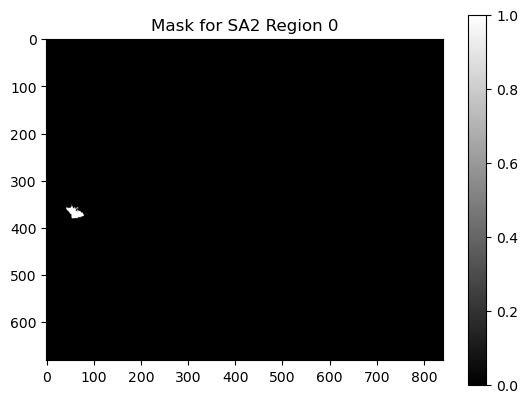

In [59]:
import matplotlib.pyplot as plt

region_index = 0  # Choose a region index
plt.imshow(mask_data[region_index, :, :], cmap="gray")
plt.title(f"Mask for SA2 Region {region_index}")
plt.colorbar()
plt.show()

